Завантаження навченої моделі

Модель 'fashion_mnist_dense.h5' успішно завантажено


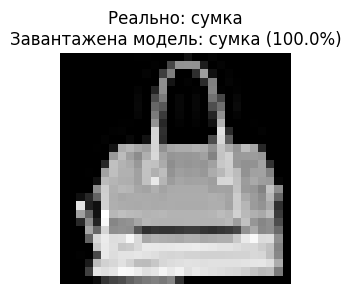

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import fashion_mnist
from PIL import Image

classes = ['футболка', 'штани', 'светр', 'плаття', 'пальто',
           'туфлі', 'сорочка', 'кросівки', 'сумка', 'черевики']

model_path = 'fashion_mnist_dense.h5'

if os.path.exists(model_path):
    loaded_model = load_model(model_path)
    print(f"Модель '{model_path}' успішно завантажено")
else:
    print(f"Файл '{model_path}' не знайдено")

(_, _), (x_test, y_test) = fashion_mnist.load_data()
x_test_flat = x_test.reshape(10000, 784) / 255.0

n_rec = 492
sample_img = x_test_flat[n_rec].reshape(1, 784)

pred = loaded_model.predict(sample_img, verbose=0)
pred_class_idx = np.argmax(pred)
confidence = np.max(pred) * 100

plt.figure(figsize=(3, 3))
plt.imshow(x_test[n_rec], cmap='gray')
plt.title(f"Реально: {classes[y_test[n_rec]]}\nЗавантажена модель: {classes[pred_class_idx]} ({confidence:.1f}%)")
plt.axis('off')
plt.show()

Тестування моделі

Знайдено 10 зображень у папці 'image_files':
['my_image.jpg', 'my_image1.jpg', 'my_image2.jpg', 'my_image3.jpg', 'my_image4.jpg', 'my_image5.jpg', 'my_image6.jpg', 'my_image7.jpg', 'my_image8.jpg', 'my_image9.jpg']


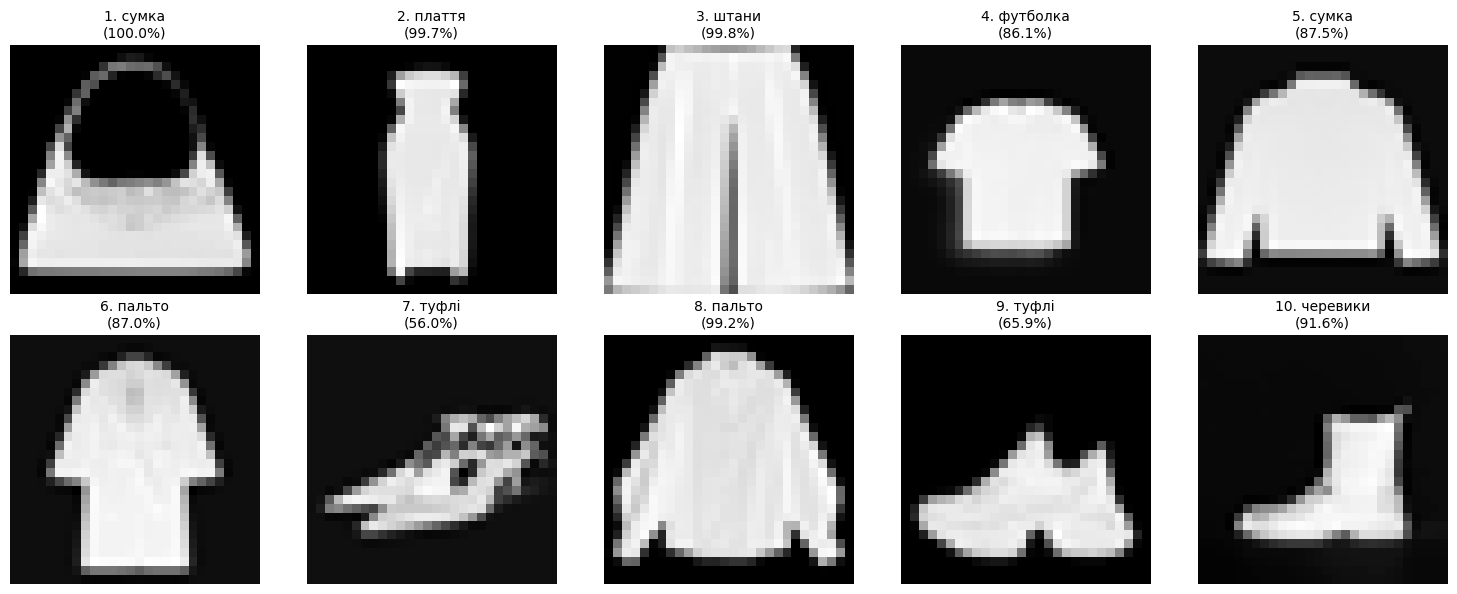

In [14]:
import os
import matplotlib.pyplot as plt

folder_name = 'image_files'

if not os.path.exists(folder_name):
    print(f"Папку '{folder_name}' не знайдено за шляхом: {os.getcwd()}")
    print("Доступні файли та папки поруч:", os.listdir('.'))
else:
    valid_ext = ('.jpg', '.jpeg', '.png', '.webp')
    found_files = [f for f in os.listdir(folder_name) if f.lower().endswith(valid_ext)]
    found_files.sort()  
    
    image_files = found_files[:10]
    
    print(f"Знайдено {len(image_files)} зображень у папці '{folder_name}':")
    print(image_files)

    plt.figure(figsize=(15, 6))
    for i, filename in enumerate(image_files):
        img_path = os.path.join(folder_name, filename)
        img_arr, pred_label, conf = predict_custom_image(img_path, loaded_model, classes)
        
        if img_arr is not None:
            plt.subplot(2, 5, i + 1)
            plt.imshow(img_arr, cmap='gray')
            plt.title(f"{i+1}. {pred_label}\n({conf:.1f}%)", fontsize=10)
            plt.axis('off')

    plt.tight_layout()
    plt.show()